<a href="https://colab.research.google.com/github/sakethnandam/exoplanet-detection/blob/main/ae_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q lightkurve astroquery pandas numpy matplotlib scikit-learn torch torchvision tqdm

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 52.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.2.0 which is incompatible.
g

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import lightkurve as lk

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [3]:
confirmed_planets = NasaExoplanetArchive.query_criteria(
    table="pscomppars",
    select="pl_name,hostname,disc_facility,pl_rade,pl_bmasse",
    where="disc_facility like '%Kepler%' or disc_facility like '%TESS%'"
)

confirmed_df = confirmed_planets.to_pandas()
print(f"Found {len(confirmed_df)} confirmed exoplanets from Kepler/TESS")
print("\nSample of confirmed planets:")
print(confirmed_df.head())

Found 3531 confirmed exoplanets from Kepler/TESS

Sample of confirmed planets:
         pl_name     hostname disc_facility   pl_rade  pl_bmasse
0  Kepler-1167 b  Kepler-1167        Kepler  1.710000      3.570
1  Kepler-1740 b  Kepler-1740        Kepler  3.323214     11.000
2  Kepler-1581 b  Kepler-1581        Kepler  0.800000      0.437
3   Kepler-644 b   Kepler-644        Kepler  3.150000     10.100
4  Kepler-1752 b  Kepler-1752        Kepler  4.540605     18.700


In [4]:
#getting kepler objects of interest
print("\nDownloading Kepler Objects of Interest (KOIs)...")

kois = NasaExoplanetArchive.query_criteria(
    table="cumulative",
    select="kepoi_name,kepid,koi_disposition,koi_period,koi_depth,koi_duration"
)

koi_df = kois.to_pandas()
print(f"Found {len(koi_df)} KOIs total")

confirmed_kois = koi_df[koi_df['koi_disposition'] == 'CONFIRMED']
candidate_kois = koi_df[koi_df['koi_disposition'] == 'CANDIDATE']
false_positive_kois = koi_df[koi_df['koi_disposition'] == 'FALSE POSITIVE']

print(f"\nBreakdown:")
print(f"  Confirmed: {len(confirmed_kois)}")
print(f"  Candidates: {len(candidate_kois)}")
print(f"  False Positives: {len(false_positive_kois)}")


Found 9564 KOIs total

Breakdown:
  Confirmed: 2746
  Candidates: 1979
  False Positives: 4839


In [5]:
#data config
SAMPLE_SIZE_PER_CLASS = 50  #small for testing, increase later
WINDOW_SIZE = 512
MAX_WINDOWS_PER_STAR = 10

print(f"Configuration:")
print(f"  Sample size per class: {SAMPLE_SIZE_PER_CLASS}")
print(f"  Window size: {WINDOW_SIZE}")
print(f"  Max windows per star: {MAX_WINDOWS_PER_STAR}")

Configuration:
  Sample size per class: 50
  Window size: 512
  Max windows per star: 10


In [6]:
def download_light_curve_safe(target_id, mission='Kepler'):
    try:
        search_result = lk.search_lightcurve(f"{mission.upper()} {target_id}", mission=mission)

        if len(search_result) == 0:
            return None

        lc = search_result[0].download()

        if lc is None:
            return None

        return lc

    except Exception as e:
        return None


def preprocess_light_curve(lc):
    try:
        lc = lc.remove_nans()
        lc = lc.normalize()
        lc = lc.flatten(window_length=301)
        flux = lc.flux.value.astype(np.float32)

        if len(flux) < WINDOW_SIZE:
            return None

        return flux

    except Exception as e:
        return None


def create_windows(flux, window_size=WINDOW_SIZE, max_windows=MAX_WINDOWS_PER_STAR):
    windows = []

    for i in range(0, len(flux) - window_size + 1, window_size):
        if len(windows) >= max_windows:
            break

        window = flux[i:i + window_size]
        median = np.median(window)
        if median > 0:
            window = window / median - 1.0
            windows.append(window)

    return windows

In [7]:
def collect_labeled_data(koi_df, label, sample_size, mission='Kepler'):
    data = []

    sampled_df = koi_df.sample(min(sample_size * 3, len(koi_df)), replace=False)

    successful = 0

    print(f"\nCollecting {label} data...")

    for idx, row in tqdm(sampled_df.iterrows(), total=len(sampled_df), desc=f"Downloading {label}"):
        if successful >= sample_size:
            break

        kepid = row['kepid']

        lc = download_light_curve_safe(kepid, mission=mission)

        if lc is None:
            continue

        flux = preprocess_light_curve(lc)

        if flux is None:
            continue

        windows = create_windows(flux)

        if len(windows) == 0:
            continue

        for window in windows:
            metadata = {
                'kepid': kepid,
                'kepoi_name': row.get('kepoi_name', ''),
                'period': row.get('koi_period', np.nan),
                'depth': row.get('koi_depth', np.nan),
                'duration': row.get('koi_duration', np.nan)
            }
            data.append((window, label, metadata))

        successful += 1

    print(f"Successfully collected {len(data)} windows from {successful} stars for {label}")

    return data

In [8]:
#collecting data for positive, candidiates, false positives
print("="*60)
print("Starting data collection...")
print("="*60)

confirmed_data = collect_labeled_data(
    confirmed_kois,
    'confirmed',
    SAMPLE_SIZE_PER_CLASS,
    mission='Kepler'
)

candidate_data = collect_labeled_data(
    candidate_kois,
    'candidate',
    SAMPLE_SIZE_PER_CLASS,
    mission='Kepler'
)

false_positive_data = collect_labeled_data(
    false_positive_kois,
    'false_positive',
    SAMPLE_SIZE_PER_CLASS,
    mission='Kepler'
)

all_data = confirmed_data + candidate_data + false_positive_data

print("\n" + "="*60)
print(f"Total data collected: {len(all_data)} windows")
print(f"  Confirmed: {len(confirmed_data)}")
print(f"  Candidates: {len(candidate_data)}")
print(f"  False Positives: {len(false_positive_data)}")
print("="*60)

Starting data collection...



Successfully collected 184 windows from 50 stars for confirmed



Successfully collected 189 windows from 50 stars for candidate



Successfully collected 233 windows from 50 stars for false_positive

Total data collected: 606 windows
  Confirmed: 184
  Candidates: 189
  False Positives: 233


In [9]:
#create metadata for analysis
metadata_list = []
for window, label, metadata in all_data:
    metadata['label'] = label
    metadata_list.append(metadata)

metadata_df = pd.DataFrame(metadata_list)

#saving metadata to .csv
metadata_df.to_csv('exoplanet_metadata.csv', index=False)
print("\nMetadata saved to 'exoplanet_metadata.csv'")
print("\nMetadata summary:")
print(metadata_df.groupby('label').size())


Metadata saved to 'exoplanet_metadata.csv'

Metadata summary:
label
candidate         189
confirmed         184
false_positive    233
dtype: int64


In [10]:
#prepare data for pytorch
X = np.array([window for window, label, metadata in all_data])
y_labels = np.array([label for window, label, metadata in all_data])

#encode labels
label_map = {'confirmed': 0, 'candidate': 1, 'false_positive': 2}
y = np.array([label_map[label] for label in y_labels])

print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nLabel distribution:")
for label_name, label_idx in label_map.items():
    count = np.sum(y == label_idx)
    print(f"  {label_name}: {count} ({count/len(y)*100:.1f}%)")

Data shape: (606, 512)
Labels shape: (606,)

Label distribution:
  confirmed: 184 (30.4%)
  candidate: 189 (31.2%)
  false_positive: 233 (38.4%)


In [11]:
#data split: 70% train, 15% val, 15% test
#first split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

#second split: split temp into 50% validation, 50% test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nData split:")
print(f"  Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")


Data split:
  Training set: 424 samples (70.0%)
  Validation set: 91 samples (15.0%)
  Test set: 91 samples (15.0%)


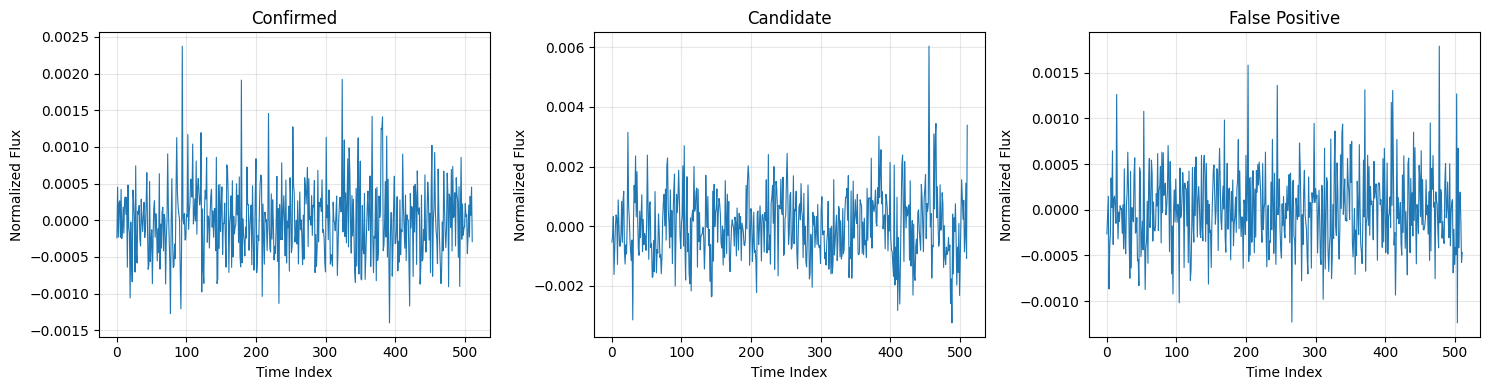

Sample light curves saved to 'sample_light_curves.png'


In [12]:
#visualize sample light curves from each class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (label_name, label_idx) in enumerate(label_map.items()):
    #find first sample of this class in training data
    sample_idx = np.where(y_train == label_idx)[0][0]
    sample = X_train[sample_idx]

    axes[idx].plot(sample, linewidth=0.8)
    axes[idx].set_title(f"{label_name.replace('_', ' ').title()}")
    axes[idx].set_xlabel("Time Index")
    axes[idx].set_ylabel("Normalized Flux")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sample_light_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample light curves saved to 'sample_light_curves.png'")

In [13]:
class LightCurveDataset(Dataset):
    """
    PyTorch Dataset for light curves.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Return (data, label)
        # Add channel dimension: (512,) -> (1, 512)
        return self.X[idx].unsqueeze(0), self.y[idx]

#create datasets
train_dataset = LightCurveDataset(X_train, y_train)
val_dataset = LightCurveDataset(X_val, y_val)
test_dataset = LightCurveDataset(X_test, y_test)

#create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataloaders created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Dataloaders created:
  Training batches: 14
  Validation batches: 3
  Test batches: 3


In [14]:
class EnhancedConvAutoencoder(nn.Module):
    """
    Enhanced Convolutional Autoencoder for exoplanet detection.

    Architecture:
    - Encoder: Progressive downsampling with batch normalization and dropout
    - Bottleneck: Compressed latent representation
    - Decoder: Progressive upsampling to reconstruct input
    """
    def __init__(self, latent_dim=32):
        super(EnhancedConvAutoencoder, self).__init__()

        #encoder
        self.encoder = nn.Sequential(
            #input: (1, 512)
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            #(32, 256)

            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            # 64, 128)

            nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            #(128, 64)

            nn.Conv1d(128, 256, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            #(256, 32)
        )

        #bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv1d(256, latent_dim, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(latent_dim, 256, kernel_size=1),
            nn.ReLU()
        )

        #decoder
        self.decoder = nn.Sequential(
            #input: (256, 32)
            nn.ConvTranspose1d(256, 128, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            #(128, 64)

            nn.ConvTranspose1d(128, 64, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            #(64, 128)

            nn.ConvTranspose1d(64, 32, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            #(32, 256)

            nn.ConvTranspose1d(32, 1, kernel_size=7, stride=2, padding=3, output_padding=1),
            #(1, 512)
        )

    def forward(self, x):
        #encode
        encoded = self.encoder(x)

        #bottleneck
        latent = self.bottleneck(encoded)

        #decode
        reconstructed = self.decoder(latent)

        return reconstructed, latent

    def encode(self, x):
        """Get latent representation"""
        encoded = self.encoder(x)
        latent = self.bottleneck(encoded)
        return latent


#initialize model
model = EnhancedConvAutoencoder(latent_dim=32).to(DEVICE)

#count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Model Architecture:
EnhancedConvAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Conv1d(128, 256, kernel_size=(7,), stride=(2,), padding=(3,))
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
  )
  (bottleneck): Sequential(
    (0): Conv1d(256, 32, kernel_size=(1,), stride=(1,))
    (1): ReLU()
   

In [17]:
#training hyperparameters
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

#loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

#learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Training configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Batch size: {BATCH_SIZE}")#training history
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rate': []
}

best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 10

print("\n" + "="*60)
print("Starting training...")
print("="*60 + "\n")

for epoch in range(EPOCHS):
    #training phase
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(DEVICE)

        #forward pass
        optimizer.zero_grad()
        reconstructed, latent = model(batch_X)

        #compute loss
        loss = criterion(reconstructed, batch_X)

        #backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    #validation phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(DEVICE)

            reconstructed, latent = model(batch_X)
            loss = criterion(reconstructed, batch_X)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    #update learning rate
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    #save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(current_lr)

    #print progress
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f} | "
          f"LR: {current_lr:.6f}")

    #save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_autoencoder_model.pth')
        print(f"  → Best model saved! (Val Loss: {val_loss:.6f})")
        patience_counter = 0
    else:
        patience_counter += 1

    #early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*60)
print("Training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")
print("="*60)


Training configuration:
  Epochs: 50
  Learning rate: 0.001
  Weight decay: 1e-05
  Batch size: 32

Starting training...

Epoch 01/50 | Train Loss: 0.631973 | Val Loss: 0.004382 | LR: 0.001000
  → Best model saved! (Val Loss: 0.004382)
Epoch 02/50 | Train Loss: 0.123697 | Val Loss: 0.002262 | LR: 0.001000
  → Best model saved! (Val Loss: 0.002262)
Epoch 03/50 | Train Loss: 0.079644 | Val Loss: 0.001180 | LR: 0.001000
  → Best model saved! (Val Loss: 0.001180)
Epoch 04/50 | Train Loss: 0.054585 | Val Loss: 0.000636 | LR: 0.001000
  → Best model saved! (Val Loss: 0.000636)
Epoch 05/50 | Train Loss: 0.040792 | Val Loss: 0.000706 | LR: 0.001000
Epoch 06/50 | Train Loss: 0.038866 | Val Loss: 0.000765 | LR: 0.001000
Epoch 07/50 | Train Loss: 0.030669 | Val Loss: 0.000682 | LR: 0.001000
Epoch 08/50 | Train Loss: 0.027985 | Val Loss: 0.000610 | LR: 0.001000
  → Best model saved! (Val Loss: 0.000610)
Epoch 09/50 | Train Loss: 0.026584 | Val Loss: 0.000510 | LR: 0.001000
  → Best model saved! (V

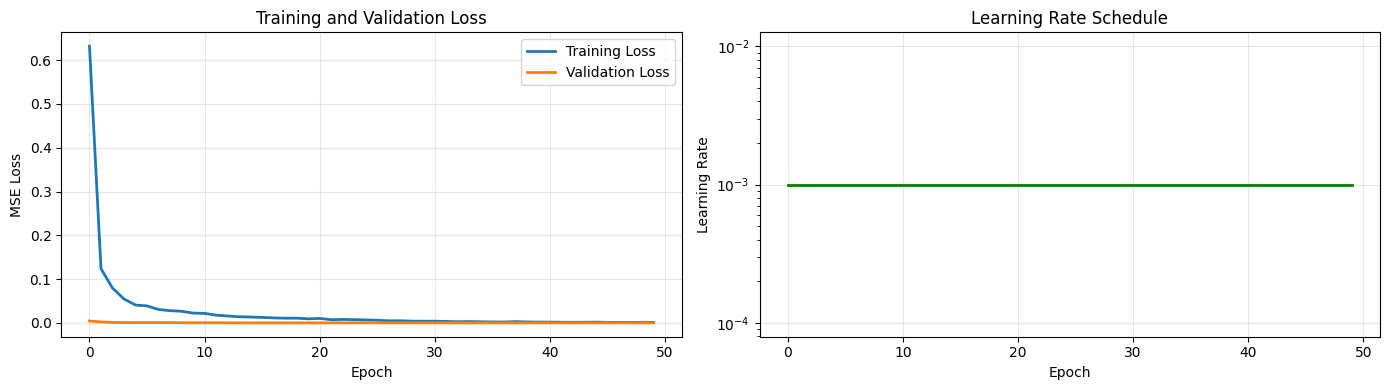

Training history saved to 'training_history.png'


In [18]:
#plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#loss plot
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#learning rate plot
axes[1].plot(history['learning_rate'], linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history saved to 'training_history.png'")

In [19]:
#load best model
model.load_state_dict(torch.load('best_autoencoder_model.pth'))
model.eval()

print("Best model loaded for evaluation")

Best model loaded for evaluation


In [20]:
def calculate_reconstruction_errors(model, dataloader):
    """
    Calculate reconstruction error (MSE) for each sample.

    Returns:
        errors: array of MSE values
        labels: array of true labels
        reconstructions: list of (original, reconstructed) tuples
    """
    model.eval()

    errors = []
    labels = []
    reconstructions = []

    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(DEVICE)

            #get reconstructions
            reconstructed, _ = model(batch_X)

            #calculate MSE for each sample
            mse = torch.mean((batch_X - reconstructed) ** 2, dim=[1, 2])

            errors.extend(mse.cpu().numpy())
            labels.extend(batch_y.cpu().numpy())

            #store some reconstructions for visualization
            if len(reconstructions) < 30:
                for i in range(min(5, len(batch_X))):
                    orig = batch_X[i, 0].cpu().numpy()
                    recon = reconstructed[i, 0].cpu().numpy()
                    reconstructions.append((orig, recon, batch_y[i].item()))

    return np.array(errors), np.array(labels), reconstructions


#calculate reconstruction errors for all sets
print("Calculating reconstruction errors...")

train_errors, train_labels, _ = calculate_reconstruction_errors(model, train_loader)
val_errors, val_labels, _ = calculate_reconstruction_errors(model, val_loader)
test_errors, test_labels, test_reconstructions = calculate_reconstruction_errors(model, test_loader)

print(f"\nReconstruction error statistics:")
print(f"  Training - Mean: {np.mean(train_errors):.6f}, Std: {np.std(train_errors):.6f}")
print(f"  Validation - Mean: {np.mean(val_errors):.6f}, Std: {np.std(val_errors):.6f}")
print(f"  Test - Mean: {np.mean(test_errors):.6f}, Std: {np.std(test_errors):.6f}")

Calculating reconstruction errors...

Reconstruction error statistics:
  Training - Mean: 0.000265, Std: 0.001896
  Validation - Mean: 0.000059, Std: 0.000204
  Test - Mean: 0.000226, Std: 0.001444


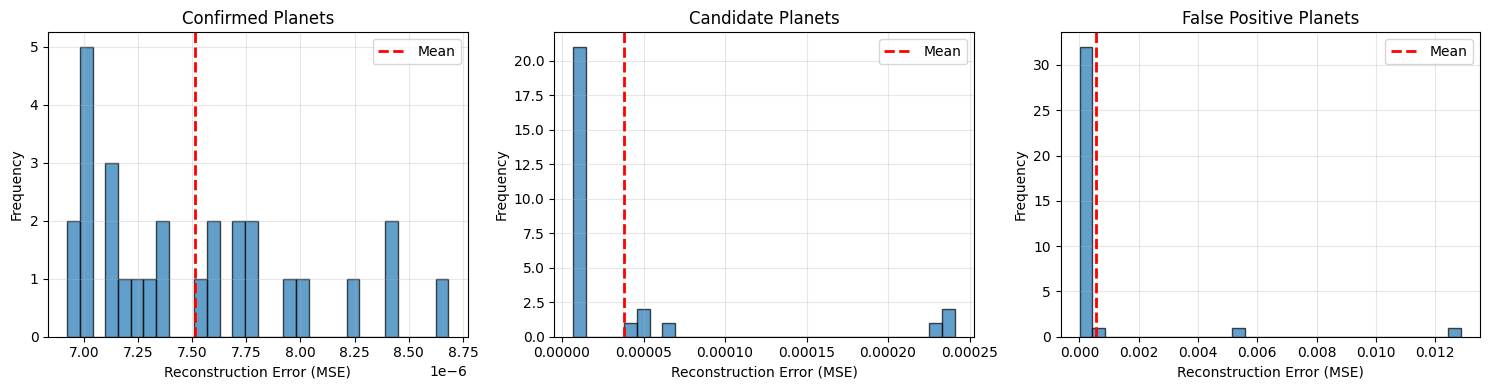

Reconstruction error distribution saved to 'reconstruction_errors_by_class.png'


In [21]:
#visualize reconstruction errors by class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_names = {0: 'Confirmed', 1: 'Candidate', 2: 'False Positive'}

for label_idx in range(3):
    mask = test_labels == label_idx
    errors_for_class = test_errors[mask]

    axes[label_idx].hist(errors_for_class, bins=30, alpha=0.7, edgecolor='black')
    axes[label_idx].axvline(np.mean(errors_for_class), color='red',
                            linestyle='--', linewidth=2, label='Mean')
    axes[label_idx].set_xlabel('Reconstruction Error (MSE)')
    axes[label_idx].set_ylabel('Frequency')
    axes[label_idx].set_title(f'{label_names[label_idx]} Planets')
    axes[label_idx].legend()
    axes[label_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reconstruction_errors_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("Reconstruction error distribution saved to 'reconstruction_errors_by_class.png'")

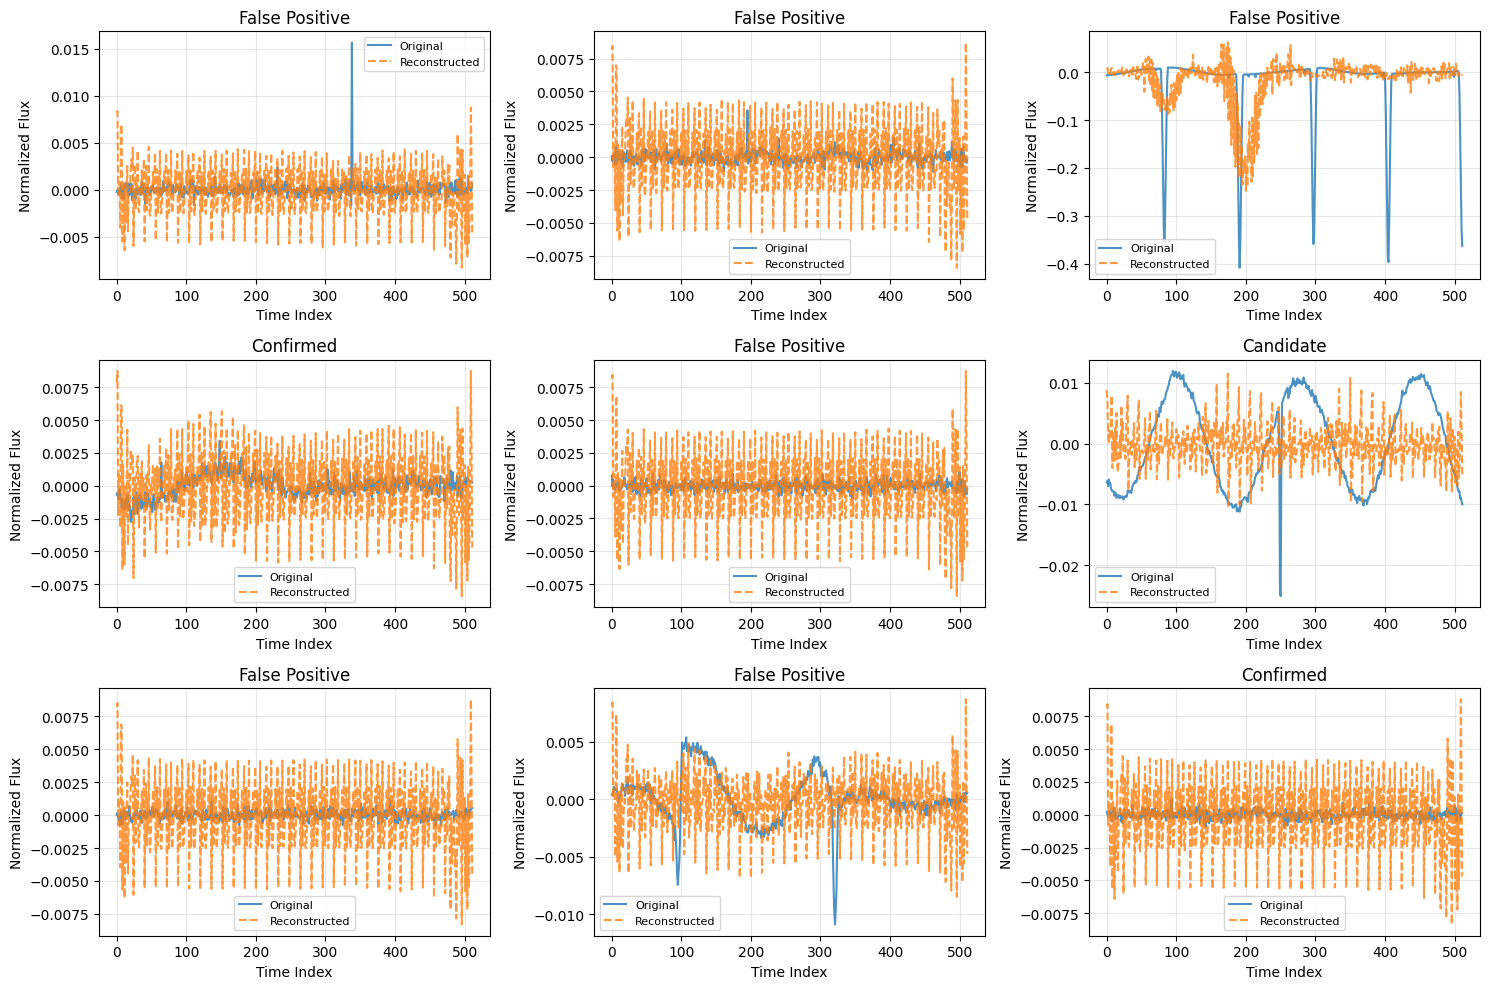

Sample reconstructions saved to 'sample_reconstructions.png'


In [22]:
#visualize sample reconstructions
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i in range(9):
    if i < len(test_reconstructions):
        orig, recon, label = test_reconstructions[i]

        row = i // 3
        col = i % 3

        axes[row, col].plot(orig, label='Original', linewidth=1.5, alpha=0.8)
        axes[row, col].plot(recon, label='Reconstructed',
                           linestyle='--', linewidth=1.5, alpha=0.8)
        axes[row, col].set_title(f"{label_names[label]}")
        axes[row, col].set_xlabel('Time Index')
        axes[row, col].set_ylabel('Normalized Flux')
        axes[row, col].legend(fontsize=8)
        axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sample_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample reconstructions saved to 'sample_reconstructions.png'")